# **Looping Graph**

In [1]:
from typing import TypedDict, Literal;
import random;

class State(TypedDict):
    target: int;
    attempts: int;
    guess: int;
    passed: bool;

def guess_node(state: State) -> dict:

    """Simulate generating an answer (random guess 1 To 5)"""

    attempts = state["attempts"] + 1;

    guess = random.randint(1, 5);

    passed = guess == state["target"];

    print(f"""
    Attempt #{attempts}
    guessed {guess} 
    target {state["target"]}
    {"✅ PASS" if passed else "❌ FAIL"}
    """);

    return {"attempts": attempts, "guess": guess, "passed": passed};

In [2]:
from langgraph.graph import StateGraph, START, END;

def should_continue(state: State) -> Literal["guess", "__end__"]:

    if state["passed"]:

        print(f"✅ Correct! Found target in {state["attempts"]} attempt(s).");

        return END;

    if state["attempts"] >= 5:

        print(f"⚠️ Max attempts reached. Stopping.");

        return END;

    print(f"🔄 Looping back to try again...");

    return "guess";

In [3]:
builder = StateGraph(State);

builder.add_node("guess", guess_node);

builder.add_edge(START, "guess");

builder.add_conditional_edges(
    "guess", # Loop Back Or END
    should_continue,
    {
        "guess": "guess",
        END: END
    }
);

graph = builder.compile();

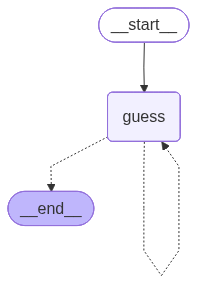

In [4]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [5]:
random.seed(2); # Repeat the Same Random Sequence.

result = graph.invoke(
    {
        "target": 3,
        "attempts": 0,
        "guess": 0,
        "passed": False
    }
);

print(f"\nFinal state: guess={result["guess"]}, attempts={result["attempts"]}, passed={result["passed"]}");


    Attempt #1
    guessed 1 
    target 3
    ❌ FAIL
    
🔄 Looping back to try again...

    Attempt #2
    guessed 2 
    target 3
    ❌ FAIL
    
🔄 Looping back to try again...

    Attempt #3
    guessed 3 
    target 3
    ✅ PASS
    
✅ Correct! Found target in 3 attempt(s).

Final state: guess=3, attempts=3, passed=True
